# Assignment: Logistic Regression on Imbalanced E-Commerce Purchase Data

## Objective

An e-commerce company wants to predict whether a visitor session will lead to a purchase.

The target column is `Revenue`:

- `True`: visitor purchased
- `False`: visitor did not purchase

This is a **binary classification problem** with class imbalance. Your goal is to train logistic regression models and compare different methods for handling imbalance.

## Business Context

If the model predicts that a visitor is likely to purchase, the company may show a discount popup, a special offer, or live sales assistance.

But there is a tradeoff:

- High **recall** means we catch more actual buyers, but may show offers to many non-buyers.
- High **precision** means fewer wasted offers, but we may miss some actual buyers.

Your final answer should recommend a model based on this business tradeoff.

## Dataset

We will use the Online Shoppers Purchasing Intention dataset.

Dataset URL:

```text
https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv
```

The dataset has website session-level features such as page visits, page durations, bounce rates, exit rates, visitor type, month, weekend flag, and whether the session generated revenue.

## Tasks

Complete the notebook by filling the `TODO` sections.

You need to compare four approaches:

1. Baseline Logistic Regression with default threshold `0.5`
2. Threshold tuning using predicted probabilities
3. Logistic Regression with `class_weight="balanced"`
4. SMOTE + Logistic Regression

For each approach, report:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Finally, answer the business questions at the end.

## 1. Setup

Run the install cell only if any package is missing.

In [ ]:
# Run this only if required.
# %pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

Load the dataset from the given URL.

In [4]:
DATA_URL = "https://raw.githubusercontent.com/sharmaroshan/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv"

# TODO: Load the dataset into a DataFrame named df.
# Hint: use pd.read_csv(DATA_URL)
df = pd.read_csv(DATA_URL)

#raise NotImplementedError("Load the dataset")

In [5]:
# TODO: Display the first 5 rows and check the shape.

#raise NotImplementedError("Inspect the dataset")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Check Class Imbalance

The target column is `Revenue`.

Check how many sessions led to purchase and how many did not.

In [6]:
# TODO: Show count and percentage distribution of df["Revenue"].
# Hint: use value_counts() and value_counts(normalize=True)

#raise NotImplementedError("Check class imbalance")
df["Revenue"].value_counts()

,count
Revenue,
False,10422
True,1908


In [7]:
df["Revenue"].value_counts(normalize=True)

,proportion
Revenue,
False,0.845255
True,0.154745


### Question 1

Is this dataset balanced or imbalanced? Why?

Write your answer here:

- The Dataset is imbalanced because only 15% of the sessions had any purchases & the rest 85% had no purchases

## 4. Select Features

To keep the assignment lightweight, we will use a limited set of useful features.

Numerical features:

```python
[
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]
```

Categorical features:

```python
["Month", "VisitorType", "Weekend"]
```

Target:

```python
"Revenue"
```

In [8]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features = ["Month", "VisitorType", "Weekend"]
target = "Revenue"

# TODO: Create X and y.
# X should contain numeric_features + categorical_features.
# y should be 1 for purchase and 0 for no purchase.
# Hint: df[target].astype(int)

#raise NotImplementedError("Create X and y")
X = df[numeric_features + categorical_features]
y = df[target].astype(int)


In [9]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,Returning_Visitor,True


In [10]:
y.head()

,Revenue
0,0
1,0
2,0
3,0
4,0


## 5. Train-Test Split

Use a stratified split so the train and test sets preserve the same class ratio.

In [11]:
# TODO: Split the data into train and test sets.
# Use test_size=0.2, random_state=RANDOM_STATE, and stratify=y.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#raise NotImplementedError("Create stratified train-test split")


In [12]:
# TODO: Check class distribution in y_train and y_test.
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)
#raise NotImplementedError("Check train-test class distribution")

(Revenue
 0    0.845296
 1    0.154704
 Name: proportion, dtype: float64,
 Revenue
 0    0.845093
 1    0.154907
 Name: proportion, dtype: float64)

### Question 2

Why did we use `stratify=y` during train-test split?

Write your answer here:

-We did this to ensure that the test data keeps the exact same proportions both in training set & test set as in the original data

## 6. Preprocessing

We will:

- Scale numeric features using `StandardScaler`
- One-hot encode categorical features using `OneHotEncoder`

The preprocessing should be fit only on the training data.

In [13]:
# TODO: Create preprocessing steps for numeric and categorical features.
# Hint:
# - Use StandardScaler() for numeric features.
# - Use OneHotEncoder(handle_unknown="ignore") for categorical features.
# - Combine both using ColumnTransformer.
# - Name the numeric transformer "num" and categorical transformer "cat".
#
# For OneHotEncoder, newer scikit-learn versions use sparse_output=False,
# while older versions use sparse=False. You can use the try-except pattern below.

try:
    numeric_transformer = StandardScaler()
except TypeError:
    numeric_transformer = StandardScaler(with_mean=False)

try:
    encoder = OneHotEncoder()  # TODO: replace None with OneHotEncoder(...)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore")  # TODO: replace None with OneHotEncoder(...)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", encoder, categorical_features)
    ]
)

#raise NotImplementedError("Create preprocessing pipeline")

## 7. Helper Function for Evaluation

Use this helper function to evaluate every model consistently.

In [17]:
def evaluate_predictions(y_true, y_pred, model_name):
    """Return a dictionary of key classification metrics."""
    # TODO: Return a dictionary with the following keys:
    # "model", "accuracy", "precision", "recall", "f1"
    #
    # Hint:
    # - "model" should store model_name.
    # - Use accuracy_score(y_true, y_pred).
    # - Use precision_score(y_true, y_pred, zero_division=0).
    # - Use recall_score(y_true, y_pred, zero_division=0).
    # - Use f1_score(y_true, y_pred, zero_division=0).
    #raise NotImplementedError("Complete evaluate_predictions function")
    #model = str(model)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1_= f1_score(y_true, y_pred, zero_division=0)
    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1_}


def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Purchase", "Purchase"],
        yticklabels=["No Purchase", "Purchase"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 8. Baseline Logistic Regression

Train a normal logistic regression model.

Use default threshold `0.5`.

In [15]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: Fit baseline_model on X_train and y_train.
# TODO: Predict on X_test and store predictions in y_pred_baseline.
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
#raise NotImplementedError("Train and predict baseline logistic regression")

{'model': 'Baseline Model', 'accuracy': 0.8787510137875101, 'precision': 0.7292817679558011, 'recall': 0.34554973821989526, 'f1': 0.4689165186500888}


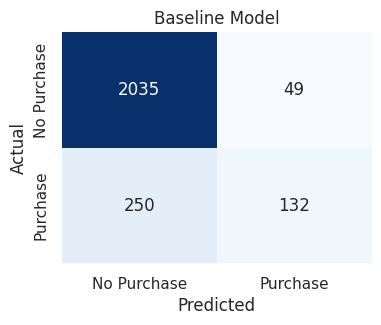

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.73      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.87      0.88      0.86      2466



In [18]:
# TODO: Evaluate baseline model using evaluate_predictions.
# TODO: Show confusion matrix.
# TODO: Print classification_report.

results = evaluate_predictions(y_test, y_pred_baseline, "Baseline Model")
print(results)
show_confusion_matrix(y_test, y_pred_baseline, "Baseline Model")
print(classification_report(y_test, y_pred_baseline))

#raise NotImplementedError("Evaluate baseline model")

## 9. Threshold Tuning

Logistic regression gives probabilities:

\[
P(y=1|x)
\]

The default threshold is usually:

\[
\text{predict purchase if } P(y=1|x) \geq 0.5
\]

But in business problems, we may change the threshold depending on whether we care more about precision or recall.

Try thresholds:

```python
[0.20, 0.30, 0.40, 0.50, 0.60]
```

In [20]:
# TODO: Get predicted probabilities for the positive class using baseline_model.predict_proba(X_test)[:, 1].
# TODO: For each threshold, convert probabilities into class predictions.
# TODO: Create a threshold comparison table with accuracy, precision, recall, and F1.

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]
baseline_model_results = []
for threshold in thresholds:
    y_pred_threshold = (baseline_model.predict_proba(X_test)[:, 1] >= threshold).astype(int)
    baseline_model_results.append(evaluate_predictions(y_test, y_pred_threshold, f"Threshold {threshold}"))
    #show_confusion_matrix(y_test, y_pred_threshold, f"Threshold {threshold}")
    #print(classification_report(y_test, y_pred_threshold))



In [21]:
baseline_model_results_df = pd.DataFrame(baseline_model_results)
baseline_model_results_df.set_index("model", inplace=True)
baseline_model_results_df

,accuracy,precision,recall,f1
model,,,,
Threshold 0.2,0.863341,0.548180,0.670157,0.603062
Threshold 0.3,0.890511,0.689189,0.534031,0.601770
Threshold 0.4,0.885239,0.712446,0.434555,0.539837
Threshold 0.5,0.878751,0.729282,0.345550,0.468917
Threshold 0.6,0.877129,0.780142,0.287958,0.420650


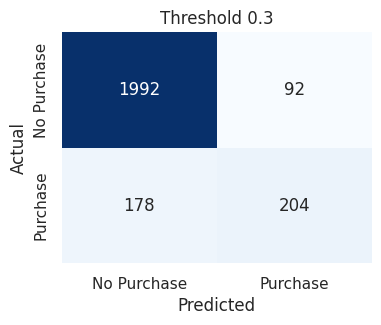

{'model': 'Threshold 0.3', 'accuracy': 0.8905109489051095, 'precision': 0.6891891891891891, 'recall': 0.5340314136125655, 'f1': 0.6017699115044248}


In [23]:
# TODO: Choose one threshold based on your business reasoning.
# Store it in selected_threshold.
# Example: selected_threshold = 0.30

selected_threshold = 0.30

# TODO: Create y_pred_threshold using selected_threshold.
# TODO: Evaluate and append result to results.
# TODO: Show confusion matrix.
y_pred_threshold = (baseline_model.predict_proba(X_test)[:, 1] >= selected_threshold).astype(int)
results = evaluate_predictions(y_test, y_pred_threshold, f"Threshold {selected_threshold}")
show_confusion_matrix(y_test, y_pred_threshold, f"Threshold {selected_threshold}")
#print(classification_report(y_test, y_pred_threshold))
print(results)

#raise NotImplementedError("Evaluate selected threshold")

### Question 3

What happens to precision and recall when you reduce the threshold?

Why does this happen?

Write your answer here:

- Lowering the classification threshold decreases precision and increases recall. By requiring less certainty to predict a "Purchase", the model becomes much more aggressive. This reduces False Negatives to boost your recall. However, it simultaneously catches more False Positives, which drives your precision down

## 10. Class-Weighted Logistic Regression

Train logistic regression with:

```python
class_weight="balanced"
```

This gives more importance to the minority class during training.

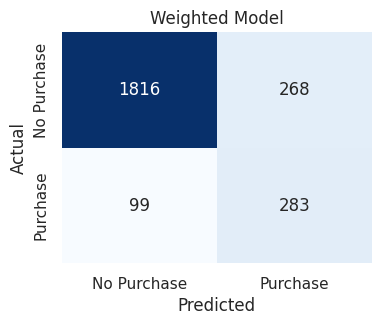

{'model': 'Weighted Model', 'accuracy': 0.85117599351176, 'precision': 0.5136116152450091, 'recall': 0.7408376963350786, 'f1': 0.6066452304394426}


In [24]:
weighted_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# TODO: Fit weighted_model on X_train and y_train.
# TODO: Predict on X_test and store predictions in y_pred_weighted.
# TODO: Evaluate and append result to results.
# TODO: Show confusion matrix.
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)
results = evaluate_predictions(y_test, y_pred_weighted, "Weighted Model")
show_confusion_matrix(y_test, y_pred_weighted, "Weighted Model")
print(results)

#raise NotImplementedError("Train and evaluate class-weighted logistic regression")

### Question 4

How did `class_weight="balanced"` change recall and precision compared to the baseline model?

Write your answer here:

- Using class_weight="balanced" increased recall and decreased precision compared to the baseline model. By heavily penalizing mistakes on the minority class ("Purchase"), the model became much more aggressive at identifying buyers. This successfully captured a lot more actual purchases (boosting recall to 74.1%), but it also resulted in more false alarms (dropping precision to 51.4%).

## 11. SMOTE + Logistic Regression

SMOTE creates synthetic minority-class examples.

Important rule:

> Apply SMOTE only on the training data, never on the test data.

For this assignment, first transform the train and test data using the preprocessor, then apply SMOTE only on the transformed training data.

In [25]:
# TODO: Fit the preprocessor on the training features.
# TODO: Use the fitted preprocessor to transform both training and test features.
#
# Hint:
# - The training set should be used to learn scaling and encoding rules.
# - The test set should only be transformed using those already-learned rules.
# - You will need one processed training feature matrix and one processed test feature matrix.

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)


#raise NotImplementedError("Preprocess train and test data for SMOTE")

In [26]:
# TODO: Apply SMOTE only on the processed training data and y_train.
#
# Hint:
# - Create a SMOTE object with RANDOM_STATE.
# - Use the SMOTE resampling method on training data only.
# - Store the resampled features and resampled target separately.
# - Do not apply SMOTE on the test data.

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

#raise NotImplementedError("Apply SMOTE on training data")

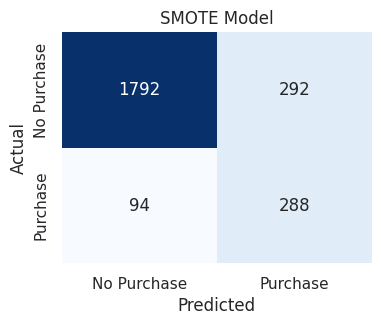

{'model': 'SMOTE Model', 'accuracy': 0.8434712084347121, 'precision': 0.496551724137931, 'recall': 0.7539267015706806, 'f1': 0.5987525987525988}


In [28]:
# TODO: Train LogisticRegression on X_train_smote and y_train_smote.
# TODO: Predict on X_test_processed.
# TODO: Evaluate and append result to results.
# TODO: Show confusion matrix.
logistic_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logistic_model.fit(X_train_smote, y_train_smote)
y_pred_smote = logistic_model.predict(X_test_processed)
results = evaluate_predictions(y_test, y_pred_smote, "SMOTE Model")
show_confusion_matrix(y_test, y_pred_smote, "SMOTE Model")
print(results)


#raise NotImplementedError("Train and evaluate SMOTE logistic regression")

### Question 5

Why should SMOTE be applied only on the training data?

Write your answer here:

- SMOTE must be applied only on the training data to prevent data leakage and ensure a realistic evaluation. If you oversample the test or validation sets, the model will be evaluated on synthetic, artificial data rather than the true, imbalanced real-world distribution. This artificially inflates your performance metrics and gives an overly optimistic, biased view of how the model will perform in production

## 12. Final Comparison

Create a final comparison table for all methods:

1. Baseline Logistic Regression
2. Threshold-Tuned Logistic Regression
3. Class-Weighted Logistic Regression
4. SMOTE + Logistic Regression

In [29]:
results_baseline = evaluate_predictions(y_test, y_pred_baseline, "Baseline Model")
results_threshold = evaluate_predictions(y_test, y_pred_threshold, f"Threshold {selected_threshold}")
results_weighted = evaluate_predictions(y_test, y_pred_weighted, "Weighted Model")
results_smote = evaluate_predictions(y_test, y_pred_smote, "SMOTE Model")

results_df = pd.DataFrame([results_baseline, results_threshold, results_weighted, results_smote])
results_df

,model,accuracy,precision,recall,f1
0,Baseline Model,0.878751,0.729282,0.345550,0.468917
1,Threshold 0.3,0.890511,0.689189,0.534031,0.601770
2,Weighted Model,0.851176,0.513612,0.740838,0.606645
3,SMOTE Model,0.843471,0.496552,0.753927,0.598753


In [30]:
# TODO: Convert results into a DataFrame and sort/format it clearly.
results_df.set_index("model", inplace=True)
results_df.sort_values(by="recall", ascending=False, inplace=True)
results_df.style.format("{:.2%}")
#raise NotImplementedError("Create final comparison table")

,accuracy,precision,recall,f1
model,,,,
SMOTE Model,84.35%,49.66%,75.39%,59.88%
Weighted Model,85.12%,51.36%,74.08%,60.66%
Threshold 0.3,89.05%,68.92%,53.40%,60.18%
Baseline Model,87.88%,72.93%,34.55%,46.89%


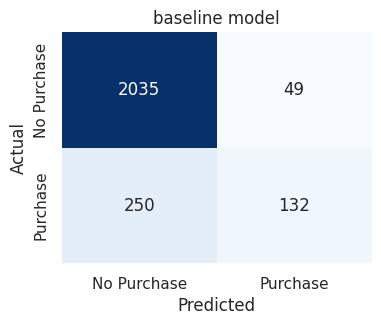

In [32]:
show_confusion_matrix(y_test, y_pred_baseline, "baseline model")

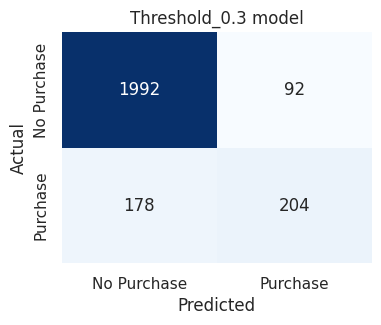

In [34]:
show_confusion_matrix(y_test, y_pred_threshold, "Threshold_0.3 model")

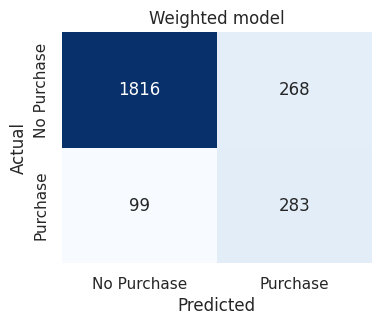

In [33]:
show_confusion_matrix(y_test, y_pred_weighted, "Weighted model")

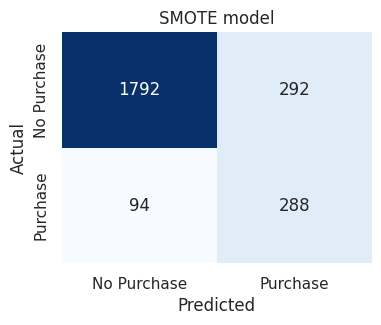

In [35]:
show_confusion_matrix(y_test, y_pred_smote, "SMOTE model")

## 13. Business Decision Questions

Answer these briefly.

### Question 6

If discount cost is high and the company wants to avoid showing offers to too many non-buyers, should it prioritize precision or recall?

Answer:

- The company should prioritize precision. Since discounts are expensive, the company needs to minimize False Positives (sending discounts to non-buyers) to avoid wasting money on people who wouldn't buy anyway

### Question 7

If missing a potential buyer is very costly, should the company prioritize precision or recall?

Answer:

- The company should prioritize recall. Since a missed opportunity is expensive, the company needs to minimize False Negatives to ensure they catch and target as many actual potential buyers as possible.

### Question 8

Which model/method would you recommend for this business problem?

Mention:

- The model/method you selected
- The metric you prioritized
- Why this decision makes business sense

Answer:

- **Selected Model: Wighted Model**
*   **Metric Prioritized: Recall (74.08%)**
*   **Business Justification:** In a highly imbalanced environment where only 15% of visitors convert, missing a potential buyer is costly for a short-term volume-growth campaign. Prioritizing the Weighted model ensures we capture the highest percentage of actual buyers (74.08%). Even though this model introduces more false positives (sending discounts to non-buyers) and carries higher short-term promotional costs, it aligns perfectly with the strategic goal of absorbing initial margins to aggressively convert window-shoppers into returning, loyal long-term customers.



## Submission Checklist

Submit your completed notebook with:

- All code cells executed
- Final comparison table
- Confusion matrices for each method
- Answers to all business questions
- A short final recommendation